# Predicción de Calidad del Aire — Beijing PM2.5
**Modelo:** LSTM apilado (2 capas) + Dense de salida  
**Entrada:** últimas 72 horas → **Salida:** próximas 24 horas  
**Dataset:** Beijing PM2.5 Air Quality (UCI ML Repository)

---
> **IMPORTANTE antes de empezar:**  
> Menú → `Entorno de ejecución` → `Cambiar tipo de entorno` → **T4 GPU** → Guardar

## Celda 1 — Instalar librerías

In [ ]:
!pip install ucimlrepo -q
print('Listo')

Listo


## Celda 2 — Importar todo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from ucimlrepo import fetch_ucirepo

print('Librerías importadas correctamente')

Librerías importadas correctamente


## Celda 3 — Descargar el dataset desde UCI

In [ ]:
# Descarga automática del dataset Beijing PM2.5 (id=381)
dataset = fetch_ucirepo(id=381)
df = dataset.data.features.copy()

print(f'Tamaño del dataset: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print('\nPrimeras filas:')
df.head()

Tamaño del dataset: (43824, 11)
Columnas: ['year', 'month', 'day', 'hour', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']

Primeras filas:


,year,month,day,hour,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,2010,1,1,0,-21,-11.0,1021.0,NW,1.79,0,0
1,2010,1,1,1,-21,-12.0,1020.0,NW,4.92,0,0
2,2010,1,1,2,-21,-11.0,1019.0,NW,6.71,0,0
3,2010,1,1,3,-21,-14.0,1019.0,NW,9.84,0,0
4,2010,1,1,4,-20,-12.0,1018.0,NW,12.97,0,0


## Celda 4 — Limpiar los datos

In [ ]:
# Añadir la columna pm2.5 al DataFrame principal
df['pm2.5'] = dataset.data.targets['pm2.5']

# Eliminar filas donde PM2.5 es nulo (es nuestra variable objetivo)
df = df.dropna(subset=['pm2.5'])

# Rellenar otros nulos con el valor anterior (forward fill)
df = df.ffill()

# Extraer solo la columna PM2.5
pm25 = df['pm2.5'].values.reshape(-1, 1)

print(f'\n Registros limpios: {len(pm25)}')


 Registros limpios: 41757


## Celda 5 — Visualizar la serie temporal

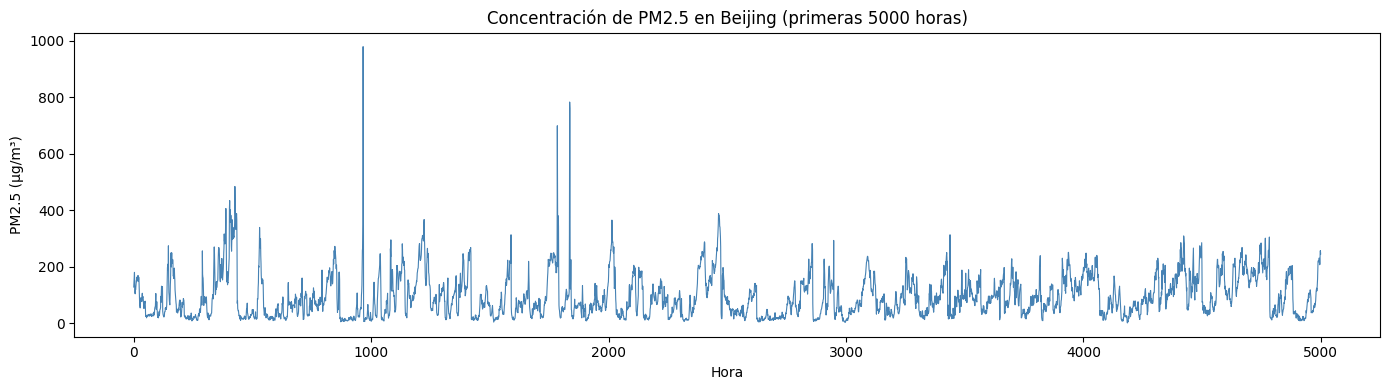

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(pm25[:5000], color='steelblue', linewidth=0.8)
plt.title('Concentración de PM2.5 en Beijing (primeras 5000 horas)')
plt.xlabel('Hora')
plt.ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

## Celda 6 — Normalizar y crear ventanas de tiempo

In [ ]:
# Normalizar entre 0 y 1
scaler = MinMaxScaler()
pm25_scaled = scaler.fit_transform(pm25)

# Función para crear secuencias
# Entrada: 72 horas pasadas → Salida: 24 horas futuras
def crear_secuencias(data, entrada=72, salida=24):
    X, y = [], []
    for i in range(len(data) - entrada - salida):
        X.append(data[i : i + entrada])
        y.append(data[i + entrada : i + entrada + salida])
    return np.array(X), np.array(y)

X, y = crear_secuencias(pm25_scaled)

print(f' X shape: {X.shape}  →  (muestras, 72 horas de entrada, 1 variable)')
print(f' y shape: {y.shape}  →  (muestras, 24 horas a predecir, 1 variable)')

 X shape: (41661, 72, 1)  →  (muestras, 72 horas de entrada, 1 variable)
 y shape: (41661, 24, 1)  →  (muestras, 24 horas a predecir, 1 variable)


## Celda 7 — Dividir en entrenamiento y prueba

In [ ]:
split = int(len(X) * 0.8)  # 80% train, 20% test

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f' Entrenamiento: {X_train.shape[0]} muestras')
print(f' Prueba:        {X_test.shape[0]} muestras')

 Entrenamiento: 33328 muestras
 Prueba:        8333 muestras


## Celda 8 — Construir el modelo LSTM apilado

In [ ]:
modelo = Sequential([
    # Capa LSTM 1: aprende patrones de corto plazo
    LSTM(64, return_sequences=True, input_shape=(72, 1)),
    Dropout(0.2),  # Evita sobreajuste

    # Capa LSTM 2: aprende patrones más complejos
    LSTM(32, return_sequences=False),
    Dropout(0.2),

    # Capa de salida: predice las próximas 24 horas
    Dense(24)
])

modelo.compile(optimizer='adam', loss='mse', metrics=['mae'])
modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 72, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,104 (117.59 KB)

 Trainable params: 30,104 (117.59 KB)

 Non-trainable params: 0 (0.00 B)

## Celda 9 — Entrenar el modelo
> Con GPU tarda ~3 minutos. Sin GPU puede tardar ~20 minutos.

In [ ]:
history = modelo.fit(
    X_train,
    y_train.reshape(y_train.shape[0], 24),
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print('\n Entrenamiento terminado')

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0065 - mae: 0.0570 - val_loss: 0.0057 - val_mae: 0.0555
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0056 - mae: 0.0521 - val_loss: 0.0054 - val_mae: 0.0539
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0054 - mae: 0.0512 - val_loss: 0.0054 - val_mae: 0.0524
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0054 - mae: 0.0506 - val_loss: 0.0053 - val_mae: 0.0518
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0053 - mae: 0.0503 - val_loss: 0.0052 - val_mae: 0.0522
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0053 - mae: 0.0501 - val_loss: 0.0052 - val_mae: 0.0517
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0053 - mae: 0.0501 - val_loss: 0.0052 - val_mae: 0.0519
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0053 - mae: 0.0499 - val_loss: 0.0052 - val_mae: 0.0510
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms

## Celda 10 — Ver curva de pérdida (loss)

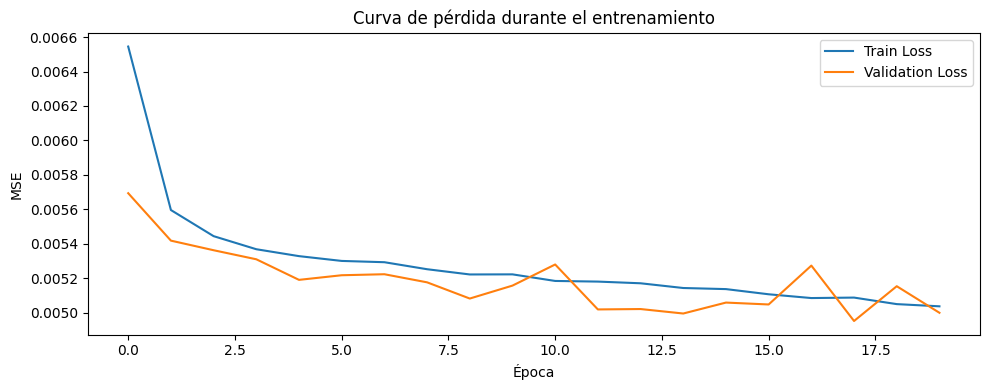

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Curva de pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

## Modelo de grafica
> Hubo picos de perdida de informacion siginficativos, lo que da a entender que los datos son muy extrapolares.

## Celda 11 — Evaluar con métricas

In [ ]:
y_pred = modelo.predict(X_test)

# Desnormalizar para ver valores reales en µg/m³
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_real = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae  = mean_absolute_error(y_test_real, y_pred_real)

print(f'📊 RMSE: {rmse:.2f} µg/m³  (error cuadrático medio)')
print(f'📊 MAE:  {mae:.2f} µg/m³   (error absoluto medio)')
print()
print('Interpretación:')
print(f'  En promedio, el modelo se equivoca ±{mae:.1f} µg/m³ en su predicción.')

261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
📊 RMSE: 70.98 µg/m³  (error cuadrático medio)
📊 MAE:  47.32 µg/m³   (error absoluto medio)

Interpretación:
  En promedio, el modelo se equivoca ±47.3 µg/m³ en su predicción.


## Modelos estadistico
> Se hace referencia con RMSE:

## Celda 12 — Gráfica final: Real vs Predicho

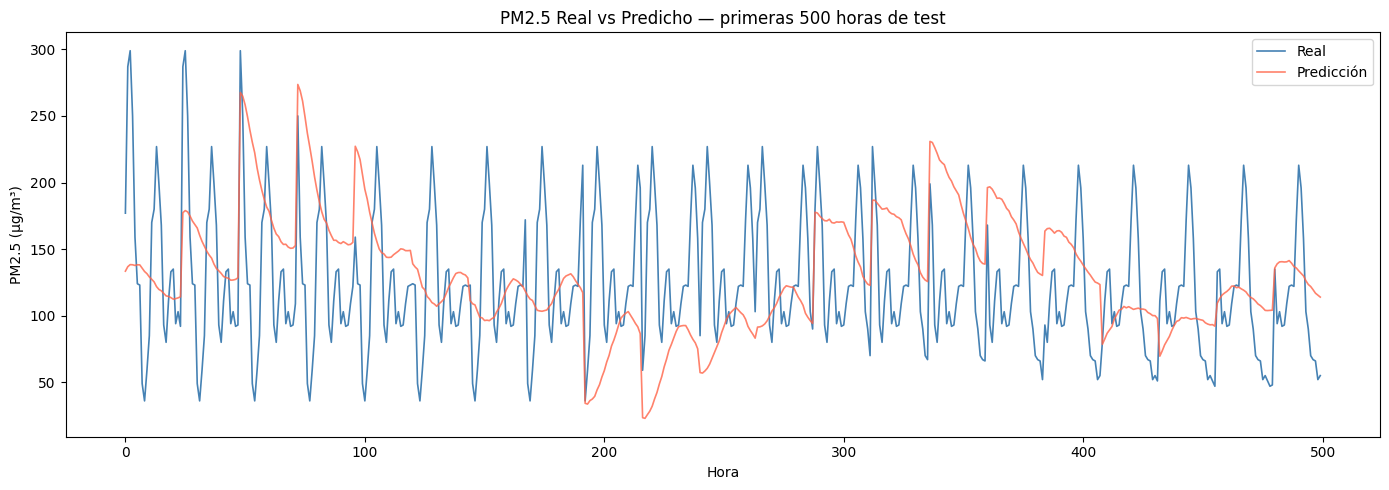

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real[:500], label='Real', color='steelblue', linewidth=1.2)
plt.plot(y_pred_real[:500], label='Predicción', color='tomato', alpha=0.8, linewidth=1.2)
plt.title('PM2.5 Real vs Predicho — primeras 500 horas de test')
plt.xlabel('Hora')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.tight_layout()
plt.show()

## Celda 13 — Guardar el modelo

In [ ]:
modelo.save('modelo_pm25.keras')
print('Modelo guardado como modelo_pm25.keras')
print('Puedes descargarlo desde el panel de archivos (ícono de carpeta a la izquierda)')

Modelo guardado como modelo_pm25.keras
Puedes descargarlo desde el panel de archivos (ícono de carpeta a la izquierda)


---
## ¡Listo!
**Lista de Tareas**
1. Descargamos el dataset Beijing PM2.5 desde UCI- Check :D
2. Limpiamos los valores nulos - Check :D
3. Normalizamos y creamos ventanas de 72h → 24h - Check :D
4. Entrenamos un modelo LSTM apilado (2 capas) - Check :D
5. Evaluamos con RMSE y MAE - Check :D
6. Visualizamos los resultados - Check :D
